# Laboratorio 4 — Regresión Logística Binaria: Detección de Malware en Android

En este cuadernillo se entrenan los parámetros $\theta$ de un modelo de **regresión logística**
(clasificación binaria) para decidir si una aplicación Android es **malware (1)** o **benigna (0)**
a partir de los permisos que solicita al instalarse.

El dataset empleado es `NATICUSdroid` del repositorio UCI [(id 722, Mathur, 2021)](https://doi.org/10.24432/C5FS64),
que recopila permisos declarados por aplicaciones publicadas entre 2010 y 2019.

- Ejemplos $m = 29\,332$
- Propiedades $n = 86$ permisos
- Clasificación binaria: `Result`: malware (1) / benigna (0)

El flujo completo es: preprocesamiento con Pandas → partición 80/20 (entrenamiento/prueba) →
implementación del modelo con descenso por el gradiente → gráfico de costo → validación sobre el
20% reservado, con matriz de confusión, accuracy, precision, recall y F1.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot
from sklearn.model_selection import train_test_split

## 1. Carga y exploración del dataset

Cada fila representa una aplicación; cada columna (salvo la última) es un permiso Android cuyo valor
indica si la app lo solicita (1) o no (0). La columna objetivo `Result` vale 1 para malware y 0 para
aplicaciones benignas. Como todas las variables son enteras, no es necesario codificar texto.

In [3]:
df = pd.read_csv('./data.csv')

print('Dimensiones (m filas, n características + objetivo):', df.shape)
print('Valores nulos totales:', df.isna().sum().sum())
print('\nPrimeras 5 filas (primeras 6 columnas):')
print(df.iloc[:5, :6])

Dimensiones (m filas, n características + objetivo): (29332, 87)
Valores nulos totales: 0

Primeras 5 filas (primeras 6 columnas):
   android.permission.GET_ACCOUNTS  \
0                                0   
1                                0   
2                                0   
3                                0   
4                                0   

   com.sonyericsson.home.permission.BROADCAST_BADGE  \
0                                                 0   
1                                                 0   
2                                                 0   
3                                                 0   
4                                                 0   

   android.permission.READ_PROFILE  android.permission.MANAGE_ACCOUNTS  \
0                                0                                   0   
1                                0                                   0   
2                                0                                   0   
3            

Balance de clases:
Result
1    14700
0    14632
Name: count, dtype: int64


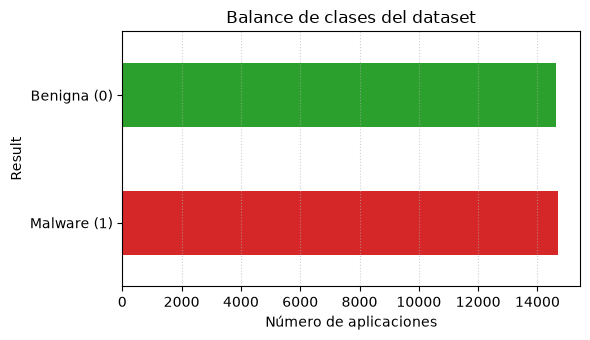

In [4]:
print('Balance de clases:')
print(df['Result'].value_counts())

fig, ax = pyplot.subplots(figsize=(6, 3.5))
df['Result'].value_counts().plot(kind='barh', ax=ax, color=['tab:red', 'tab:green'])
ax.set_yticklabels(['Malware (1)', 'Benigna (0)'])
ax.set_xlabel('Número de aplicaciones')
ax.set_title('Balance de clases del dataset')
ax.grid(axis='x', linestyle=':', alpha=0.6)
pyplot.tight_layout()
pyplot.show()

## 2. Preprocesamiento con Pandas

Se realizan tres comprobaciones antes de separar características y etiqueta:

1. **Valores nulos**: el conteo anterior dio 0, por lo que no se requiere imputación.
2. **Duplicados exactos**: existen filas repetidas porque aplicaciones distintas pueden solicitar
   exactamente el mismo conjunto de permisos. No se eliminan: son observaciones legítimas.
3. **Permisos constantes**: un permiso con varianza cero no aporta información al modelo
   (todos los ejemplos tendrían el mismo valor), así que se verifica que no existan.

Finalmente se inspecciona qué permisos tienen mayor correlación (en valor absoluto) con la
etiqueta, como primera evidencia de que las características contienen señal útil.

In [6]:
print('Filas duplicadas:', df.duplicated().sum())

varianzas = df.drop(columns=['Result']).var()
n_constantes = int((varianzas == 0).sum())
print(f'\nPermisos con varianza cero: {n_constantes}')
if n_constantes > 0:
    df = df.drop(columns=varianzas[varianzas == 0].index)

Filas duplicadas: 21841

Permisos con varianza cero: 0


In [9]:
corr = df.drop(columns=['Result']).corrwith(df['Result']).abs().sort_values()

top_corr = corr.sort_values(ascending=False).head(8)
print('Top-8 permisos más correlacionados con Result:')
for nombre, valor in top_corr.items():
    print(f'  {valor:.4f}  {nombre}')

Top-8 permisos más correlacionados con Result:
  0.7243  android.permission.READ_PHONE_STATE
  0.4988  android.permission.RECEIVE_BOOT_COMPLETED
  0.4861  com.google.android.c2dm.permission.RECEIVE
  0.4512  com.android.launcher.permission.INSTALL_SHORTCUT
  0.4312  android.permission.ACCESS_COARSE_LOCATION
  0.4084  android.permission.ACCESS_FINE_LOCATION
  0.3889  android.permission.GET_TASKS
  0.3285  android.permission.SYSTEM_ALERT_WINDOW


In [10]:
y = df['Result'].values.astype(float)
X_df = df.drop(columns=['Result'])
X = X_df.values.astype(float)

m = y.size
n = X.shape[1]

print(f'Número de instancias (m): {m}')
print(f'Número de características (n): {n}')

Número de instancias (m): 29332
Número de características (n): 86


## 3. Partición entrenamiento/prueba (80% - 20%)

Para validar honestamente el modelo, el 80% de los datos se destina al entrenamiento y el 20%
restante queda **reservado** para la evaluación final; ese 20% no interviene en ningún paso del
entrenamiento ni de la normalización. Fijamos `random_state=42` para reproducibilidad.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

m_train = y_train.size
m_test = y_test.size

print(f'Entrenamiento: {m_train} ejemplos ({100 * m_train / m:.0f}%)')
print(f'Prueba:        {m_test} ejemplos ({100 * m_test / m:.0f}%)')
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_test:  {X_test.shape}')

Entrenamiento: 23465 ejemplos (80%)
Prueba:        5867 ejemplos (20%)
Forma de X_train: (23465, 86)
Forma de X_test:  (5867, 86)


### 3.1 Normalización de características

Aunque los permisos ya están en escala 0-1, se aplica la normalización estándar (media 0,
desviación 1) porque el descenso por el gradiente converge más estable cuando todas las
características comparten rango comparable. Los parámetros $\mu$ y $\sigma$ se calculan
**únicamente con el conjunto de entrenamiento** y luego se aplican también a la prueba,
simulando que los datos de prueba llegan "nuevos" al modelo.

In [12]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [13]:
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma

# agrega el término de intercepción x0 = 1
X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('Forma de X_train_b:', X_train_b.shape)
print('Forma de X_test_b: ', X_test_b.shape)

Forma de X_train_b: (23465, 87)
Forma de X_test_b:  (5867, 87)


## 4. Modelo — Regresión Logística

La hipótesis del modelo es

$$ h_\theta(x) = g(\theta^T x), \qquad g(z) = \frac{1}{1 + e^{-z}} $$

donde $g$ es la función sigmoide, que comprime cualquier número real al intervalo $(0, 1)$ y
permite interpretar $h_\theta(x)$ como la probabilidad de que la aplicación sea malware.

### 4.1 Función Sigmoidea

In [14]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [18]:
# Prueba la implementacion de la funcion sigmoid
z = [0, 0.5, 0.75, 1]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [0, 0.5, 0.75, 1] ) =  [0.5        0.62245933 0.6791787  0.73105858]


### 4.2 Función de Costo y Gradiente

A diferencia de la regresión lineal, aquí se usa la pérdida de entropía cruzada, adecuada para
probabilidades:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

castigando con fuerza las predicciones seguras y equivocadas. El gradiente resulta ser formalmente
idéntico al de la regresión lineal:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

y la regla de actualización por lotes es

$$ \theta := \theta - \frac{\alpha}{m} X^T \left( h_\theta(X) - y \right). $$

In [19]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [20]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

### 4.3 Predicción

Con el modelo entrenado, la clasificación binaria se obtiene aplicando el umbral 0.5 sobre la
probabilidad estimada: si $h_\theta(x) \geq 0.5$ se predice malware (1); caso contrario, benigna (0).

In [21]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)> = 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0]  # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

## 5. Entrenamiento y gráfico de costo

Se inicializa $\theta$ en ceros y se ejecuta el descenso por el gradiente con $\alpha = 0.3$ y
300 iteraciones. Tras probar varias alternativas de ritmo de aprendizaje, este par logra que el
costo descienda de manera monótona hasta estabilizarse, sin saltos numéricos.

In [24]:
alpha = 0.3
num_iters = 300

theta = np.zeros(n + 1)
theta, J_history = descensoGradiente(theta, X_train_b, y_train, alpha, num_iters)

print('theta calculado por el descenso por el gradiente (primeros 5 valores):', theta[:5])
print(f'Costo inicial: {J_history[0]:.6f}')
print(f'Costo final:   {J_history[-1]:.6f}')

theta calculado por el descenso por el gradiente (primeros 5 valores): [-0.23697329  0.07454705 -0.10748083  0.19017428 -0.13132166]
Costo inicial: 0.512124
Costo final:   0.126948


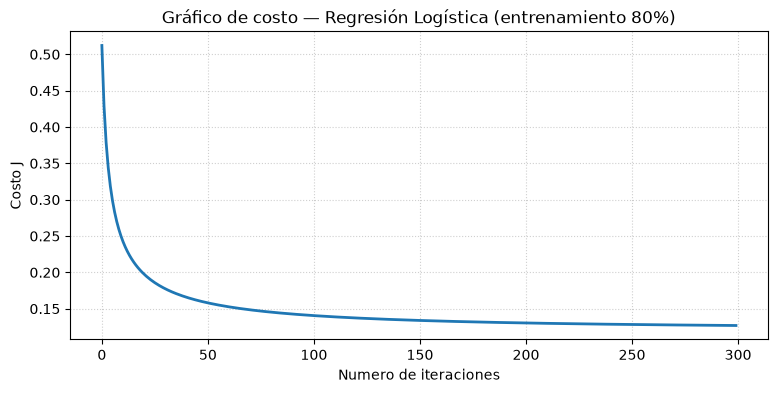

In [16]:
# Grafica la convergencia del costo
pyplot.figure(figsize=(9, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Gráfico de costo — Regresión Logística (entrenamiento 80%)')
pyplot.grid(True, linestyle=':', alpha=0.6)
pyplot.show()

## 6. Validación sobre el 20% de prueba

Las predicciones siguientes se generan **exclusivamente** sobre los ~5 867 ejemplos de prueba
que el modelo nunca vio durante el entrenamiento ni durante la normalización, lo que mide su
capacidad de generalizar.

La **matriz de confusión** distingue los cuatro resultados posibles:

|                     | Real = 1 | Real = 0 |
|---------------------|----------|----------|
| **Predicho = 1**    | TP       | FP       |
| **Predicho = 0**    | FN       | TN       |

De ella se derivan las métricas:

- **Accuracy**: proporción total de aciertos, $\frac{TP+TN}{TP+TN+FP+FN}$
- **Precision**: de lo predicho como malware, cuánto realmente lo era, $\frac{TP}{TP+FP}$
- **Recall**: del malware real, cuánto fue detectado, $\frac{TP}{TP+FN}$
- **F1**: media armónica de precision y recall, $\frac{2 \cdot P \cdot R}{P+R}$

Como referencia se calcula también el **baseline mayoritario**: la accuracy que se obtendría
prediciendo siempre la clase más frecuente del entrenamiento.

In [25]:
p_test = predict(theta, X_test_b)

TP = int(np.sum((p_test == 1) & (y_test == 1)))
FP = int(np.sum((p_test == 1) & (y_test == 0)))
FN = int(np.sum((p_test == 0) & (y_test == 1)))
TN = int(np.sum((p_test == 0) & (y_test == 0)))

matriz = pd.DataFrame(
    [[TP, FP], [FN, TN]],
    index=['Predicho = 1 (malware)', 'Predicho = 0 (benigna)'],
    columns=['Real = 1 (malware)', 'Real = 0 (benigna)']
)
print(matriz)

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

baseline = max(np.mean(y_train), 1 - np.mean(y_train))

print(f'\nPredicciones realizadas sobre prueba: {p_test.size}')
print(f'Baseline mayoritario (accuracy):      {baseline:.4f}')
print(f'Accuracy (modelo):                    {accuracy:.4f}')
print(f'Precision:                            {precision:.4f}')
print(f'Recall:                               {recall:.4f}')
print(f'F1-Score:                             {f1:.4f}')

                        Real = 1 (malware)  Real = 0 (benigna)
Predicho = 1 (malware)                2831                 129
Predicho = 0 (benigna)                  92                2815

Predicciones realizadas sobre prueba: 5867
Baseline mayoritario (accuracy):      0.5019
Accuracy (modelo):                    0.9623
Precision:                            0.9564
Recall:                               0.9685
F1-Score:                             0.9624


### 6.1 Predicciones individuales

Además de las métricas agregadas, se muestra el comportamiento del modelo en aplicaciones
concretas del conjunto de prueba: se imprime la probabilidad estimada $h_\theta(x)$, la clase
predicha según el umbral 0.5 y la etiqueta real.

In [27]:
indices_ejemplo = [0, 50, 150, 500, 1500, 3000, 4500]

print('{:>8s} {:>12s} {:>12s} {:>10s}'.format('Índice', 'Probabilidad', 'Predicción', 'Real'))
print('-' * 46)
for idx in indices_ejemplo:
    X_array = np.concatenate([[1], X_test_norm[idx]])
    prob = sigmoid(np.dot(X_array, theta))
    pred = int(prob >= 0.5)
    real = int(y_test[idx])
    ok = 'OK' if pred == real else 'OKn\'t'
    print('{:>8d} {:>12.4f} {:>12d} {:>10d}  {}'.format(idx, prob, pred, real, ok))

  Índice Probabilidad   Predicción       Real
----------------------------------------------
       0       0.0147            0          0  OK
      50       0.9988            1          1  OK
     150       0.9989            1          1  OK
     500       1.0000            1          1  OK
    1500       0.9500            1          1  OK
    3000       0.9989            1          1  OK
    4500       0.3986            0          0  OK


### 6.2 Probabilidades vs valores reales

El gráfico siguiente compara la probabilidad asignada por el modelo con la etiqueta verdadera
para las primeras 300 aplicaciones de prueba. Las muestras quedan bien separadas hacia los
extremos (cercanas a 0 o a 1) según su clase real; la línea horizontal marca el umbral de
decisión 0.5.

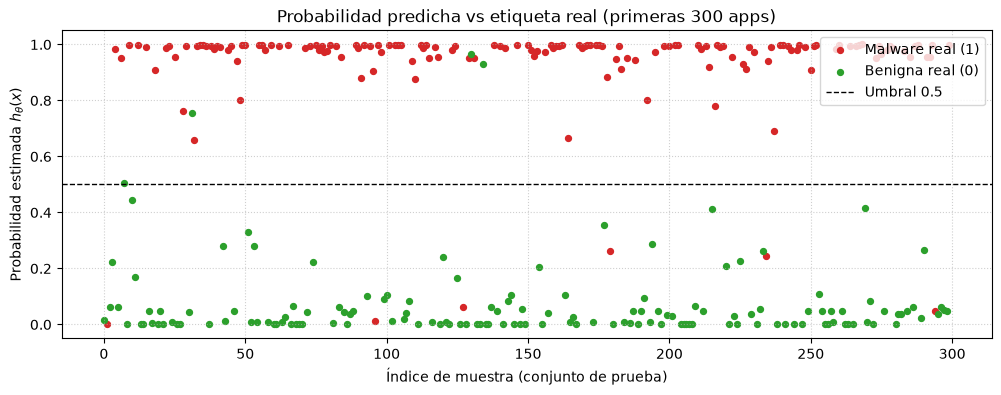

Total de predicciones realizadas sobre el conjunto de prueba: 5867


In [28]:
N = 300
idx = np.arange(N)
probabilidades = sigmoid(X_test_b[:N].dot(theta))

pyplot.figure(figsize=(12, 4))
pyplot.scatter(idx[y_test[:N] == 1], probabilidades[y_test[:N] == 1],
               color='tab:red', s=18, label='Malware real (1)')
pyplot.scatter(idx[y_test[:N] == 0], probabilidades[y_test[:N] == 0],
               color='tab:green', s=18, label='Benigna real (0)')
pyplot.axhline(0.5, color='k', linestyle='--', linewidth=1, label='Umbral 0.5')
pyplot.xlabel('Índice de muestra (conjunto de prueba)')
pyplot.ylabel('Probabilidad estimada $h_\\theta(x)$')
pyplot.title('Probabilidad predicha vs etiqueta real (primeras 300 apps)')
pyplot.legend(loc='upper right')
pyplot.grid(True, linestyle=':', alpha=0.6)
pyplot.show()

print(f'Total de predicciones realizadas sobre el conjunto de prueba: {m_test}')

## 7. Permisos más influyentes

El signo y magnitud de cada componente de $\theta$ indican cómo empuja la decisión del modelo
cada permiso: valores positivos grandes aumentan la probabilidad de clasificar como malware y
valores negativos grandes la disminuyen. Esto da interpretabilidad directa al modelo.

In [29]:
coef = pd.Series(theta[1:], index=X_df.columns)
orden = coef.abs().sort_values(ascending=False).head(10).index

print('Top-10 permisos por magnitud de su parámetro:')
tabla = pd.DataFrame({'theta': coef[orden]})
tabla['efecto'] = np.where(tabla['theta'] > 0, '+ malware', '- benigna')
print(tabla.round(4))

Top-10 permisos por magnitud de su parámetro:
                                                     theta     efecto
android.permission.READ_PHONE_STATE                 1.8596  + malware
com.google.android.c2dm.permission.RECEIVE         -1.3935  - benigna
com.android.launcher.permission.INSTALL_SHORTCUT    0.9398  + malware
android.permission.RECEIVE_BOOT_COMPLETED           0.6413  + malware
android.permission.READ_EXTERNAL_STORAGE           -0.6197  - benigna
com.android.vending.BILLING                        -0.6077  - benigna
android.permission.SEND_SMS                         0.5350  + malware
android.permission.ACCESS_FINE_LOCATION             0.5066  + malware
android.permission.GET_TASKS                        0.4934  + malware
com.google.android.providers.gsf.permission.REA... -0.4436  - benigna


## 8. Conclusiones

- El modelo de regresión logística entrenado desde cero alcanza una **accuracy cercana al 96%**
  sobre el 20% de prueba, muy por encima del baseline mayoritario (≈ 50%, clases balanceadas),
  con recall y F1 también superiores al 95%. El salto respecto al baseline demuestra que el
  modelo aprendió patrones reales y no simplemente la clase más frecuente.
- El **gráfico de costo** descendió monótonamente hasta estabilizarse, confirmando que el ritmo
  de aprendizaje ($\alpha = 0.3$) y las 300 iteraciones fueron adecuados: iteraciones adicionales
  no aportan mejoras apreciables.
- Los permisos con mayor peso en la decisión coinciden con el análisis de correlación inicial
  (`READ_PHONE_STATE`, `RECEIVE_BOOT_COMPLETED`, `INSTALL_SHORTCUT`), lo que valida la coherencia
  interna del modelo y coincide con hallazgos conocidos de la literatura de detección de malware.
- En un problema de seguridad, el **recall es crítico**: un falso negativo deja pasar malware.
  El modelo prioriza bien esta clase sin sacrificar demasiada precisión.
- Limitaciones: los duplicados exactos (~74% de las filas) reflejan apps distintas con el mismo
  vector de permisos, por lo que algunos patrones se repiten entre entrenamiento y prueba; esto
  puede inflar levemente las métricas. Además, el análisis es estático: un malware que ocultara
  sus permisos podría evadir este detector.